In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
calls = pd.read_csv("eugene_springfield_calls.csv")
calls.head()

,Incident Number,Year,Responding Agency,Initial Call Type,Final Call Type
0,15000043,2015,EPD,ASSAULT,ARREST
1,15000116,2015,EPD,FIGHT,ARREST
2,15000117,2015,EPD,FIGHT,ARREST
3,15000175,2015,EPD,CRIMINAL TRESPASS,ARREST
4,15000185,2015,EPD,DISORDERLY SUBJECT,ARREST


### group number of arrests based on year and agency

In [28]:
arrest_counts = calls.groupby(["Year", "Responding Agency"]).size().reset_index(name="Total Arrests")
arrest_counts

,Year,Responding Agency,Total Arrests
0,2015,EPD,3756
1,2015,SPD,3023
2,2016,EPD,3995
3,2016,SPD,3575
4,2017,EPD,4027
5,2017,SPD,4115
6,2018,EPD,3733
7,2018,SPD,3499
8,2019,EPD,4111
9,2019,SPD,3247


### Create line plot using seaborn to visualize number of arrests in a yearly timeline

<Axes: xlabel='Year', ylabel='Total Arrests'>

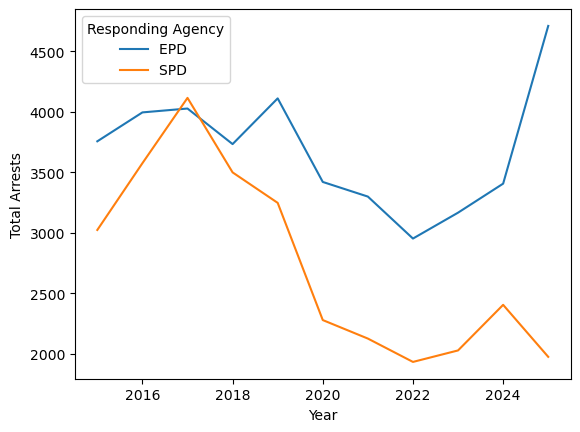

In [29]:
sns.lineplot(data=arrest_counts, x="Year", y="Total Arrests", hue="Responding Agency")

### Create a bar graph using seaborn to compare number of arrests in Eugene and in Springfield for year 2025, year CAHOOTS was inoperable in Eugene 

In [37]:
filter2025 = calls["Year"].isin([2025])
calls2025 = calls[filter2025]
calls2025.head()

,Incident Number,Year,Responding Agency,Initial Call Type,Final Call Type
35865,25000154,2025,EPD,SUSPICIOUS CONDITIONS,ARREST
35866,25000389,2025,EPD,CRIMINAL TRESPASS,ARREST
35867,25000562,2025,EPD,BURGLARY,ARREST
35868,25000576,2025,EPD,DISORDERLY SUBJECT,ARREST
35869,25000667,2025,EPD,DISPUTE,ARREST


### Find out top 10 most frequent initial call types

In [41]:
most_frequent = calls2025["Initial Call Type"].value_counts()
most_frequent.head(10)

Initial Call Type
PATROL CHECK               1012
CRIMINAL TRESPASS           541
DISPUTE                     478
DISORDERLY SUBJECT          410
TRFSTP                      317
PERSON STOP                 299
TRSPS                       220
TRAFFIC STOP                193
DSPUT                       174
LOCATION WANTED SUBJECT     152
Name: count, dtype: int64

### Create Grouped Bar plot

In [42]:
filter_initial_calls = calls2025["Initial Call Type"].isin(["PATROL CHECK", "CRIMINAL TRESPASS", "DISPUTE", "DISORDERLY SUBJECT",
                                                       "TRFSTP", "PERSON STOP", "TRSPS", "TRAFFIC STOP", "DSPUT", "LOCATION WANTED SUBJECT"])
calls_filtered= calls2025[filter_initial_calls]
calls_filtered.head()

,Incident Number,Year,Responding Agency,Initial Call Type,Final Call Type
35866,25000389,2025,EPD,CRIMINAL TRESPASS,ARREST
35868,25000576,2025,EPD,DISORDERLY SUBJECT,ARREST
35869,25000667,2025,EPD,DISPUTE,ARREST
35870,25000688,2025,EPD,PERSON STOP,ARREST
35871,25000769,2025,EPD,PERSON STOP,ARREST


In [43]:
arrests2025 = calls_filtered.groupby(["Initial Call Type", "Responding Agency"]).size().reset_index(name="Arrests")
arrests2025.head()

,Initial Call Type,Responding Agency,Arrests
0,CRIMINAL TRESPASS,EPD,541
1,DISORDERLY SUBJECT,EPD,410
2,DISPUTE,EPD,478
3,LOCATION WANTED SUBJECT,EPD,152
4,PATROL CHECK,EPD,1012


<Axes: xlabel='Initial Call Type', ylabel='Arrests'>

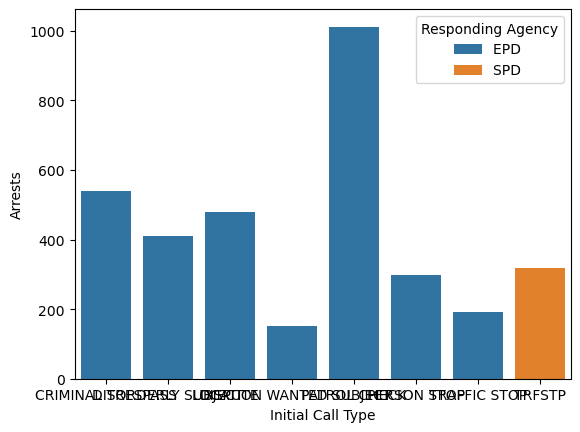

In [44]:
sns.barplot(arrests2025, x="Initial Call Type", y="Arrests", hue="Responding Agency")